<a href="https://colab.research.google.com/github/aurabinda90-dev/CFD-in-Python/blob/main/Step_7_2D_Linear_Convection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Step 7: 2D Linear Convection

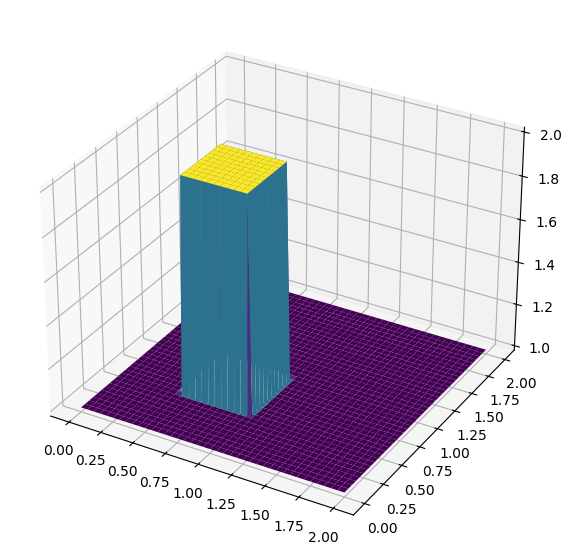

In [ ]:
from mpl_toolkits.mplot3d import Axes3D #New library required for projected 3d plots
import numpy as np
from matplotlib import pyplot as plt, cm

#variables declarations

nx = 81
ny = 81
nt = 100
c = 1

dx = 2 / (nx - 1)
dy = 2 / (ny - 1)
sigma =.2
dt = sigma * dx

x = np.linspace(0,2,nx)
y = np.linspace(0,2,nx)

u = np.ones((nx,ny)) # create 2d array of 1's
un = np.ones((nx,ny)) # placeholder

## inital conditions

# set hat function I.C.: u(0.5<=x<=1 && 0.5<=y<=1) = 2
u[int(0.5/dx):int(1/dx + 1),int(0.5/dy):int(1/dy + 1)] = 2

#plot initical condition
fig = plt.figure(figsize = (11,7), dpi=100)
ax = fig.add_subplot(111, projection='3d')
# The '111' means a grid of 1 row and 1 column and this subplot is the first one.
X, Y = np.meshgrid(x,y)
surf = ax.plot_surface(X,Y,u,cmap=cm.viridis)

#Iterating in two dimensions

In [ ]:
%%timeit
u = np.ones((nx,ny))
u[int(0.5/dx):int(1/dx + 1),int(0.5/dy):int(1/dy + 1)] = 2

#loop across number of time steps
for n in range(nt):
    un = u.copy()
    row, col = u.shape
    for i in range(1,row):
        for j in range(1,col):
            u[i,j] = (un[i,j] - (c * dt / dx * (un[i,j] - un[i-1,j])) -
                                (c * dt / dy * (un[i,j] - un[i,j-1])))
            u[0,:] = 1
            u[:,0] = 1

2.64 s ± 499 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


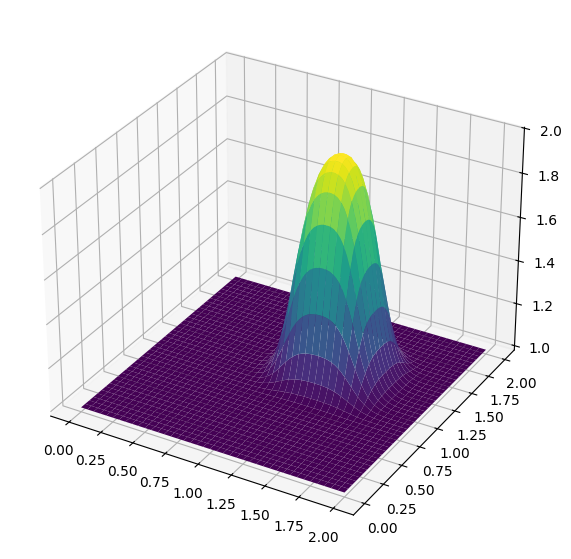

In [ ]:
u = np.ones((nx,ny))
u[int(0.5/dx):int(1/dx + 1),int(0.5/dy):int(1/dy + 1)] = 2

#loop across number of time steps
for n in range(nt):
    un = u.copy()
    row, col = u.shape
    for i in range(1,row):
        for j in range(1,col):
            u[i,j] = (un[i,j] - (c * dt / dx * (un[i,j] - un[i-1,j])) -
                                (c * dt / dy * (un[i,j] - un[i,j-1])))
            u[0,:] = 1
            u[:,0] = 1

fig = plt.figure(figsize = (11,7), dpi=100)
ax = fig.add_subplot(111, projection='3d')
# The '111' means a grid of 1 row and 1 column and this subplot is the first one.
X, Y = np.meshgrid(x,y)
surf = ax.plot_surface(X,Y,u,cmap=cm.viridis)

#Array Operations

In [ ]:
%%timeit
u = np.ones((nx,ny))
u[int(0.5/dx):int(1/dx + 1),int(0.5/dy):int(1/dy + 1)] = 2

# loop across number of time steps
for n in range(nt):
    un = u.copy()
    u[1:,1:] = (un[1:,1:] - (c * dt / dx * (un[1:,1:] - un[:-1,1:])) -
                            (c * dt / dy * (un[1:,1:] - un[1:,:-1])))
    u[0,:] = 1
    u[:,0] = 1


6.3 ms ± 426 µs per loop (mean ± std. dev. of 7 runs, 100 loops each)


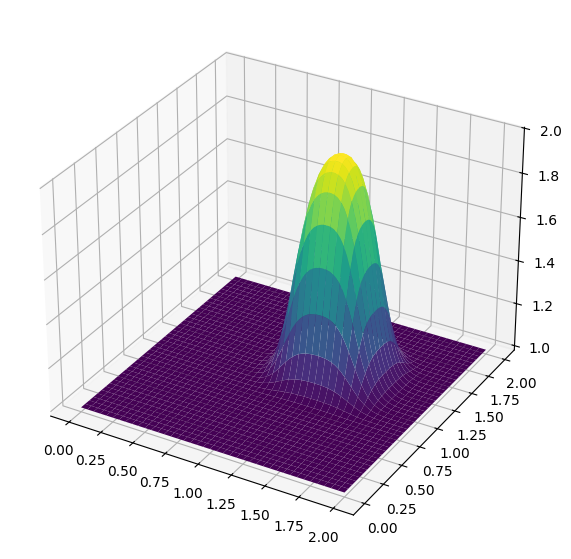

In [ ]:
u = np.ones((nx,ny))
u[int(0.5/dx):int(1/dx + 1),int(0.5/dy):int(1/dy + 1)] = 2

# loop across number of time steps
for n in range(nt):
    un = u.copy()
    u[1:,1:] = (un[1:,1:] - (c * dt / dx * (un[1:,1:] - un[:-1,1:])) -
                            (c * dt / dy * (un[1:,1:] - un[1:,:-1])))
    u[0,:] = 1
    u[:,0] = 1


fig = plt.figure(figsize = (11,7), dpi=100)
ax = fig.add_subplot(111, projection='3d')
# The '111' means a grid of 1 row and 1 column and this subplot is the first one.
X, Y = np.meshgrid(x,y)
surf = ax.plot_surface(X,Y,u,cmap=cm.viridis)

It’s evident that the array operations approach significantly outperforms the for-loop method in terms of speed and efficiency!

